# Pulse arrival times from the Crab pulsar
## Crab Pulsar Experiment Part 3.2

Use this notebook as a template for Part 3.2 of the Crab pulsar experiment.

In [22]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np

# The interpolate library from scipy includes powerful interpolation routines
# including the Lagrange interpolation described in the lab script.
from scipy import interpolate

# Astropy provides many useful tools...
from astropy import coordinates as coord
from astropy import units as u
from astropy import constants as const
from astropy import time as astrotime

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from math import pi

## Load Data
Here we load your ToA data as well as the file containing solar system barycentre coordinates.

In [23]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# A good test to do is if you can see the contents of the directory in which you work on your google drive.
# Here "My Drive" refers to the "root" of your google drive.
# By default your notebook should be in a directory called Colab Notebooks.
# This template assumes all files you want to read in are copied in the
# same directory. Note the slash at the end of the first line.

#==============================================================================================================
#pathcrabtemplate = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
#pathcrabtemplate = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
pathcrabtemplate = rootpathdrive+'/'+'My Drive/Colab Notebooks/CrabPulsar/Crab_pulsar_template/' #Sara's directory
#==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathcrabtemplate):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.

['README.md', 'LICENSE', 'template.txt', '.gitignore', '20251007_100808_B0329+54.npz', '20251007_110422_B0950+08.npz', '20251007_121203_B1933+16.npz', '20251007_134605_B2021+51.npz', '2025_ssb.txt', '20251021_071206_B0531+21.npz.toas.txt', '20251007_121203_B1933+16.npz.toas.txt', '20251111_091248_B1133+16.npz', '20251111_054931_B0531+21.npz', '20251111_114643_B1929+10.npz', '20251021_083354_B0531+21.npz', '20251119_184501_B0531+21.npz', '20251119_184501_B0531+21.npz.toas.txt', '20251111_054931_B0531+21.npz.toas.txt', 'WORKING Make Time of Arrivals.ipynb', '20251111_130236_B2016+28.npz', '20251021_134059_B2020+28.npz', '20251021_071206_B0531+21.npz', '20251021_102701_B1133+16.npz', '20251111_113619_B1919+21.npz', '20251125_100607_B1804-08.npz', '20251125_121227_B1642-03.npz', 'WORKING Searching for Pulsars.ipynb', 'Questions in Script + FAQ.gdoc', 'Finley and Sara - Digital Lab Notebook .gslides', 'Interview Presentation.gslides', 'Untitled drawing.gdraw', 'WORKING Dedispersion and data

In [25]:
# Specify the file with ToAs you want to work on.
toafile  = os.path.join(pathcrabtemplate,"20251111_054931_B0531+21.npz.toas.txt")
baryfile = os.path.join(pathcrabtemplate,"2025_ssb.txt") # ssb_2022 will work for all of 2022.

# Read the barycentre file... Read the numpy loadtxt page to understand what this does...
year, month, day, xpos, ypos, zpos = np.loadtxt(baryfile,unpack=True)
year = year
month = month
day = day
xpos = xpos
ypos = ypos
zpos = zpos

#print(year)
# @todo: Load in your ToAs in a similar way.
toa_day, toa_uncertainty = np.loadtxt(toafile,unpack=True)

In [26]:
from astropy.time import Time

def ymd_to_mjd_array_astropy(year, month, day):
    """
    Convert year, month, day (0h UT) to Modified Julian Date (MJD) using Astropy.
    Supports scalar or NumPy array inputs.
    """
    # Create datetime strings in ISO format
    dates = [f"{int(y)}-{int(m):02d}-{int(d):02d}" for y, m, d in zip(year, month, day)]

    # Create Astropy Time object
    t = Time(dates, format='iso')

    # Return MJD
    return t.mjd

# Use Astropy for conversion
barycentre_mjd = ymd_to_mjd_array_astropy(year, month, day)

# Step 2: Apply the date window
lower_limit = 60968
upper_limit = 60971

measurement_mask = (barycentre_mjd >= lower_limit) & (barycentre_mjd <= upper_limit)

# Step 3: Filter all arrays
barycentre_mjd_new = barycentre_mjd[measurement_mask]
xpos_new = xpos[measurement_mask]
ypos_new = ypos[measurement_mask]
zpos_new = zpos[measurement_mask]

print(barycentre_mjd_new)

[60968. 60969. 60970. 60971.]


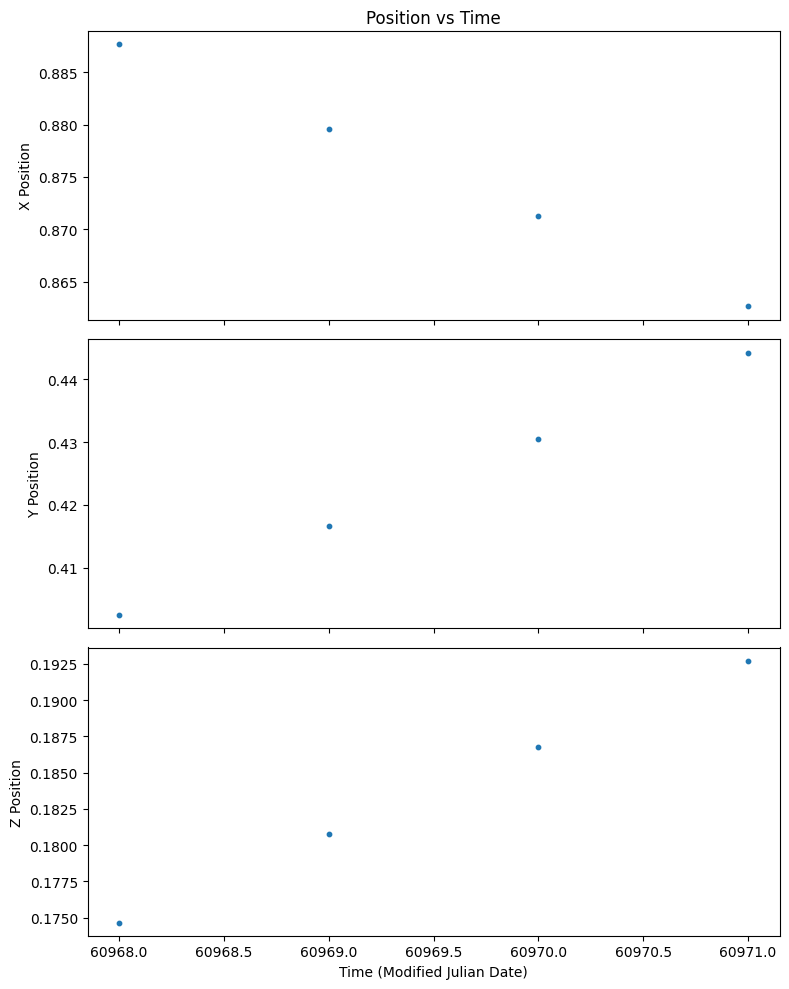

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# X position
axes[0].scatter(barycentre_mjd_new, xpos_new, s=10)
axes[0].set_ylabel("X Position")
axes[0].set_title("Position vs Time")

# Y position
axes[1].scatter(barycentre_mjd_new, ypos_new, s=10)
axes[1].set_ylabel("Y Position")

# Z position
axes[2].scatter(barycentre_mjd_new, zpos_new, s=10)
axes[2].set_ylabel("Z Position")
axes[2].set_xlabel("Time (Modified Julian Date)")

plt.tight_layout()
plt.show()


## Interpolation
The Earth-barycentre vector is only given once per day (at 0 UT) in your input file. Therefore you will need to [interpolate](https://en.wikipedia.org/wiki/Interpolation) to get the vector at the time of each of your ToAs.

The below is an example code showing interpolation of a simple sinusoid function. Make sure you understand what this code is doing, then replace it with a function to interpolate your x, y and z positions at the times of your ToAs.

[-4.94252582e+05  1.62214875e+01 -1.33098000e-04]


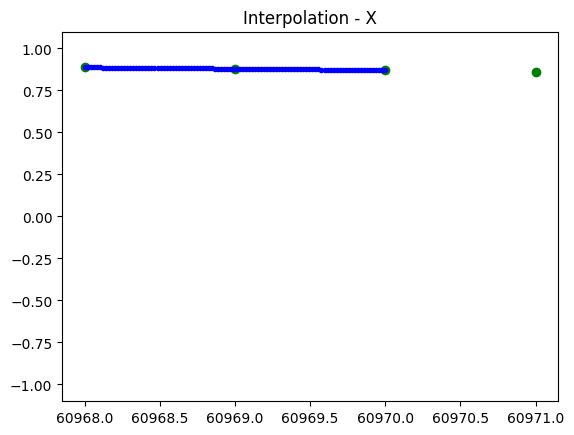

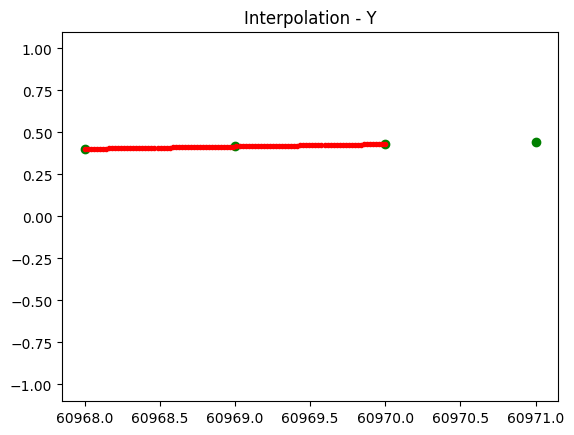

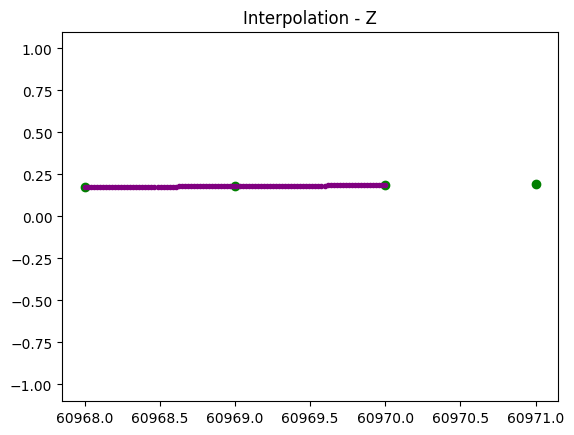

In [28]:
# Interpolation Valyes
start_point = 0
interp_number=3

# For x coordinate
x = barycentre_mjd_new
y_x = xpos_new

interp_function_x = interpolate.lagrange(x[start_point:start_point+interp_number],\
                                        y_x[start_point:start_point+interp_number])

x2 = np.linspace(x[start_point], x[start_point + interp_number - 1], 100)
y2_x = interp_function_x(x2)

from numpy.polynomial.polynomial import Polynomial
print(Polynomial(interp_function_x.coef[::-1]).coef)

plt.plot(x, y_x, 'o', color='green')
plt.plot(x2, y2_x, '.', color='blue')
plt.ylim(-1.1, 1.1)
plt.title("Interpolation - X")
plt.show()

xpos_at_times = interp_function_x(toa_day)

# For y coordinate
y_y = ypos_new

interp_function_y = interpolate.lagrange(x[start_point:start_point+interp_number],\
                                        y_y[start_point:start_point+interp_number])

y2_y = interp_function_y(x2)

plt.plot(x, y_y, 'o', color='green')
plt.plot(x2, y2_y, '.', color='red')
plt.ylim(-1.1, 1.1)
plt.title("Interpolation - Y")
plt.show()

ypos_at_times = interp_function_y(toa_day)

# For z coordinate
y_z = zpos_new

interp_function_z = interpolate.lagrange(x[start_point:start_point+interp_number],\
                                        y_z[start_point:start_point+interp_number])

y2_z = interp_function_z(x2)

plt.plot(x, y_z, 'o', color='green')
plt.plot(x2, y2_z, '.', color='purple')
plt.ylim(-1.1, 1.1)
plt.title("Interpolation - Z")
plt.show()

zpos_at_times = interp_function_z(toa_day)

# Print or save all interpolated coordinates
# print("Interpolated coordinates at TOA days:")
# print(f"X positions: {xpos_at_times}")
# print(f"Y positions: {ypos_at_times}")
# print(f"Z positions: {zpos_at_times}")


coordinates_array = np.column_stack((xpos_at_times, ypos_at_times, zpos_at_times))

In [29]:
# Example: check how well the interpolation predicts nearby actual data points
actual_values = ypos_new[start_point:start_point+interp_number+1]  # one more real point
predicted_values = interp_function_y(x[start_point:start_point+interp_number+1])
residuals = actual_values - predicted_values
error = np.sqrt(np.mean(residuals**2))  # RMS error
print("RMS interpolation error:", error)


RMS interpolation error: 2.340674442403175e-06


## Compute the Earth delay

This is the delay due to the fact that the observatory is not at the centre of the Earth. For this, you need to know the elevation angle above the horizon (see the lab script for more details).

The [Astropy](http://www.astropy.org/) library provides very powerful tools to do things like coordinate transforms. Here we want to convert from equitorial (RA and Dec) coordinate system to an observatory-based [AltAz](http://docs.astropy.org/en/stable/api/astropy.coordinates.AltAz.html) coordinate system. Make sure you are familiar with these two coordinate systems. The conversion from one to the other requries knowing the location of your telecsope and also the time the observations were taken.

The following libraries have been imported for your convinience:
 * ``astropy.coordinate`` has been imported as ``coord``
 * ``astropy.time`` has been imported as ``astrotime``


Altitudes (deg): [39d50m54.74061945s 39d23m40.14112985s 38d54m52.45410083s
 38d25m57.9773182s 37d56m57.61235749s 37d27m50.87000558s
 36d58m38.54479764s 36d29m20.93348895s 35d59m58.38104173s
 35d30m31.14789936s 35d00m59.78609995s 34d31m24.69420908s
 34d01m45.05655678s 33d32m02.86001829s 33d02m17.58344354s
 32d32m29.23372169s 32d02m38.85022561s 31d32m45.95171041s
 31d02m51.20735815s 30d32m55.19573141s 30d02m57.59557787s
 29d32m58.93297142s 29d02m59.1128318s 28d32m59.05058026s
 28d02m58.67691608s 27d32m58.23956255s 27d02m57.98424709s
 26d32m58.15290255s 26d02m58.98269565s 25d33m00.71185795s
 25d03m03.57098392s 24d33m07.79138204s 24d03m13.29828193s
 23d33m20.92344149s 23d03m30.28472992s 22d33m42.20988149s
 22d03m56.61600928s 21d34m13.7215646s 21d04m34.0436733s 20d34m57.19593226s
 20d05m23.69362375s 19d35m53.45088729s 19d13m48.6817029s]
Azimuths (deg): [252d29m57.09378317s 253d15m03.454527s 254d02m06.37889806s
 254d48m43.46646238s 255d34m54.70123221s 256d20m42.25217036s
 257d06m06.21087896s

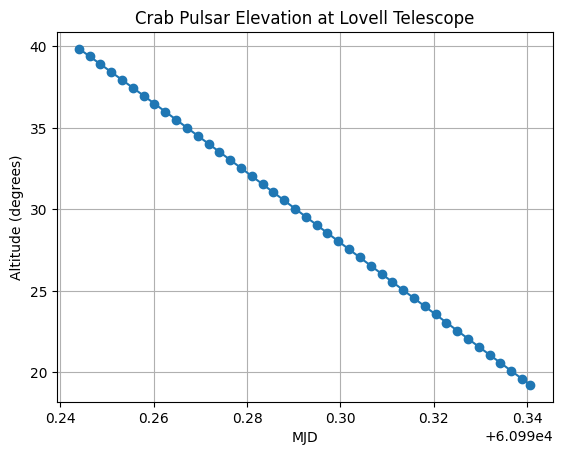

Earth delay (s): [0.01363221 0.01350234 0.01336416 0.01322449 0.0130834  0.01294086
 0.01279693 0.01265165 0.01250503 0.0123571  0.01220792 0.01205752
 0.01190584 0.01175305 0.01159912 0.01144406 0.01128795 0.01113077
 0.01097259 0.01081347 0.01065339 0.0104924  0.0103305  0.0101678
 0.0100043  0.00984003 0.00967502 0.00950932 0.00934296 0.00917597
 0.00900838 0.00884024 0.00867155 0.00850241 0.00833279 0.00816278
 0.0079924  0.00782168 0.00765068 0.00747939 0.00730786 0.00713611
 0.00700724]


In [30]:
from astropy import constants as const


# Crab Pulsar position
pulsarpos = coord.SkyCoord(ra="05:34:31.9", dec="+22:00:52.0",
                           unit=(u.hourangle, u.deg))

lovellpos = coord.EarthLocation(
    lat="53:14:09", lon="-2:18:23", height=126.3*u.m
)

times = Time(toa_day, format='mjd', scale='utc')

# Transform to AltAz
altaz = pulsarpos.transform_to(coord.AltAz(obstime=times, location=lovellpos))

# Check output
print("Altitudes (deg):", altaz.alt)
print("Azimuths (deg):", altaz.az)

# Optional plot
plt.plot(times.mjd, altaz.alt.deg, 'o-')
plt.xlabel("MJD")
plt.ylabel("Altitude (degrees)")
plt.title("Crab Pulsar Elevation at Lovell Telescope")
plt.grid(True)
plt.show()


# Get altitude in radians
elevation_rad = altaz.alt.to(u.rad).value  # numeric array in radians

# Constants
R_earth = const.R_earth.value  # meters
c = const.c.value              # m/s

# Compute Earth delay
earth_delay = (R_earth * np.sin(elevation_rad)) / c  # seconds

print("Earth delay (s):", earth_delay)


## Compute the Roemer delay

This is the delay corresponding to the distance of the centre of the Earth to the barycentre.
$$
\Delta_{Rsun} = \frac{1}{c} \vec{r}_{vec} \cdot \hat{\vec{s}} = -\frac{1}{c} \left( \vec{r}_{SSB} + \vec{r}_{EO} \right) \cdot \hat{\vec{s}}
$$


[403.20712957 403.21881576 403.23111588 403.24341437 403.25570757
 403.2680016  403.2802934  403.2925834  403.30487163 403.31715861
 403.32944289 403.34172389 403.3540095  403.36628814 403.37856553
 403.39084365 403.40311743 403.41539211 403.42766506 403.43993423
 403.45220371 403.46447173 403.47674073 403.48900625 403.50127052
 403.51353361 403.52579551 403.53805629 403.55031594 403.56257454
 403.57483209 403.58708865 403.59934633 403.61160101 403.62385686
 403.63610979 403.64836191 403.66061325 403.67286176 403.68511165
 403.69736085 403.7096115  403.71879599] s
Roemer delay (s) for each TOA:
[403.20712957 403.21881576 403.23111588 403.24341437 403.25570757
 403.2680016  403.2802934  403.2925834  403.30487163 403.31715861
 403.32944289 403.34172389 403.3540095  403.36628814 403.37856553
 403.39084365 403.40311743 403.41539211 403.42766506 403.43993423
 403.45220371 403.46447173 403.47674073 403.48900625 403.50127052
 403.51353361 403.52579551 403.53805629 403.55031594 403.56257454
 4

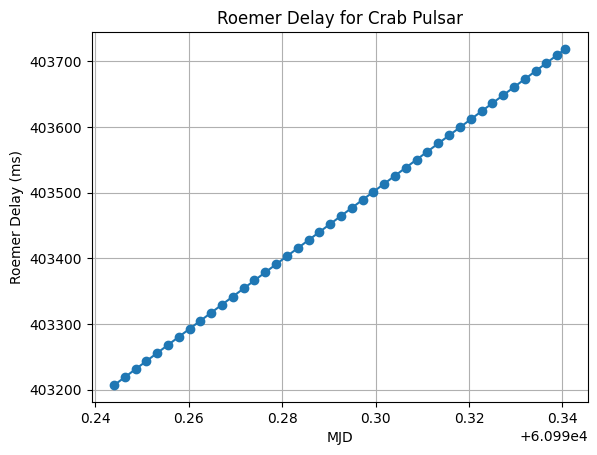

In [31]:
c = const.c

# Barycentre positions at ToA and subsequently our observation coords (centre of earth)
psr_x = xpos_at_times
psr_y = ypos_at_times
psr_z = zpos_at_times
r_ssb = np.column_stack((xpos_at_times, ypos_at_times, zpos_at_times))  # Earth to barycentre vector at TOA

# Converting pulsar's RA and Dec coords into cartesian
pulsar_cart = pulsarpos.icrs.cartesian
s_hat = np.array([pulsar_cart.x.value,
                  pulsar_cart.y.value,
                  pulsar_cart.z.value])
s_hat /= np.linalg.norm(s_hat)  # ensure it's a unit vector

r_ssb_q = r_ssb * const.au  # corrected r_ssb in metres

# Fix: Add units to r_sine to make it consistent
r_sine = (R_earth * np.sin(elevation_rad)) * u.m  # Add units explicitly, is the term: (r_EO . s^ )

# Calculate the dot product and ensure proper units
dot_product = np.dot(r_ssb_q, s_hat)  # This has units of meters

roemer_delay = (1/c) * (dot_product + r_sine)

print(roemer_delay)
print("Roemer delay (s) for each TOA:")
print(roemer_delay)

plt.plot(toa_day, roemer_delay.to(u.ms), 'o-')
plt.xlabel("MJD")
plt.ylabel("Roemer Delay (ms)")
plt.title("Roemer Delay for Crab Pulsar")
plt.grid(True)
plt.show()



In [32]:
# Convert Time object to MJD values (plain numbers)
times_mjd = times.mjd  # This gives the numerical MJD values

print("Times MJD values:", times_mjd)

# Convert Roemer delay from seconds to days (since MJD is in days)
roemer_delay_days = roemer_delay.to(u.day)

# Add the delays
corrected_time_mjd = times_mjd + roemer_delay_days.value

print("Corrected times (MJD):", corrected_time_mjd)

# Convert back to Time object:
corrected_time = Time(corrected_time_mjd, format='mjd')
print("Corrected Time objects:", corrected_time)

Times MJD values: [60990.24409747 60990.24629651 60990.24861144 60990.25092643
 60990.25324077 60990.25555562 60990.2578704  60990.26018518
 60990.26249996 60990.26481483 60990.26712951 60990.2694439
 60990.27175946 60990.27407401 60990.27638863 60990.27870367
 60990.28101818 60990.28333314 60990.28564805 60990.28796252
 60990.2902773  60990.29259205 60990.29490724 60990.29722202
 60990.2995368  60990.30185158 60990.30416636 60990.30648113
 60990.30879591 60990.31111069 60990.31342547 60990.31574025
 60990.31805542 60990.3203702  60990.32268537 60990.32500015
 60990.32731492 60990.3296297  60990.33194409 60990.33425887
 60990.33657365 60990.33888882 60990.34062461]
Corrected times (MJD): [60990.24876421 60990.2509634  60990.25327847 60990.25559359
 60990.25790808 60990.26022308 60990.262538   60990.26485292
 60990.26716784 60990.26948286 60990.27179768 60990.27411221
 60990.27642791 60990.2787426  60990.28105736 60990.28337255
 60990.2856872  60990.2880023  60990.29031735 60990.2926319

## Residuals from a fixed period model - WORKING PROGRESS



Since $$m = f_{test} - f_{true}$$
$$ P_{true} = \frac{-1}{m - \frac{1}{P_{test}}}
$$

and when we plot $P_{true}$ against the elapsed time we can see that it worked

In [33]:
# # Constants
SECONDS_PER_DAY = 86400.0

# # Initial model period estimate (in seconds)

#print(corrected_time_mjd)
print("Original corrected times:", len(corrected_time_mjd))
period_guess = 0.033847826  # seconds



#print("New corrected times:", len(corrected_time_mjd))

#Time elapsed calculations


#time_elapsed = delta_t_seconds

indices_to_remove = [0, 2, 3, 4, 9, 13, 15, 17, 18, 21]
corrected_time_mjd = np.delete(corrected_time_mjd, indices_to_remove)
toa_uncertainty = np.delete(toa_uncertainty, indices_to_remove)
#time_elapsed = np.delete(time_elapsed, indices_to_remove)

t0_mjd = corrected_time_mjd[0]
delta_t_seconds = (corrected_time_mjd - t0_mjd) * SECONDS_PER_DAY
time_elapsed = delta_t_seconds
# Initial residuals using period_guess
N = time_elapsed / period_guess
N_int = np.round(N)                    # best-fit integer cycle count
residuals = N - N_int                  # phase residuals in cycles


def correct_residuals(data):
    """Correct residuals by detecting jumps between ±0.5 cycles and unwrapping."""
    result = data.copy()
    offset = 0

    for i in range(1, len(data)):
        # Calculate the difference between current and previous point
        diff = data[i] - data[i-1]

        # If there's a large positive jump (likely wrap from ~+0.5 to ~-0.5)
        if diff < -0.5:  # Jump from positive to negative
            offset += 1
            #print(f"Positive jump at index {i}: {data[i-1]:.3f} -> {data[i]:.3f}, offset now: {offset}")

        # If there's a large negative jump (likely wrap from ~-0.5 to ~+0.5)
        elif diff > 0.5:  # Jump from negative to positive
            offset -= 1
            #print(f"Negative jump at index {i}: {data[i-1]:.3f} -> {data[i]:.3f}, offset now: {offset}")

        # Apply the current offset to this point
        result[i] = data[i] + offset

    return result
# Apply the correction
residuals_new = correct_residuals(residuals)

###
T = 0.01  # threshold for change compared to previous point


mask = np.ones(len(residuals_new), dtype=bool)
#mask = (residuals_new[1:] - residuals_new[:-1]) <= T

# Apply mask to EVERYTHING that depends on the same indices
residuals_new = residuals_new[mask]
corrected_time_mjd = corrected_time_mjd[mask]
toa_uncertainty = toa_uncertainty[mask]
time_elapsed = time_elapsed[mask]
print("New corrected times:", len(corrected_time_mjd))

####
#mask = np.abs(residuals_new) <= 0.15

# Apply mask to all relevant arrays
#residuals_new = residuals_new[mask]
#time_elapsed = time_elapsed[mask]
#corrected_time_mjd = corrected_time_mjd[mask]
#toa_uncertainty = toa_uncertainty[mask]

Original corrected times: 43
New corrected times: 33


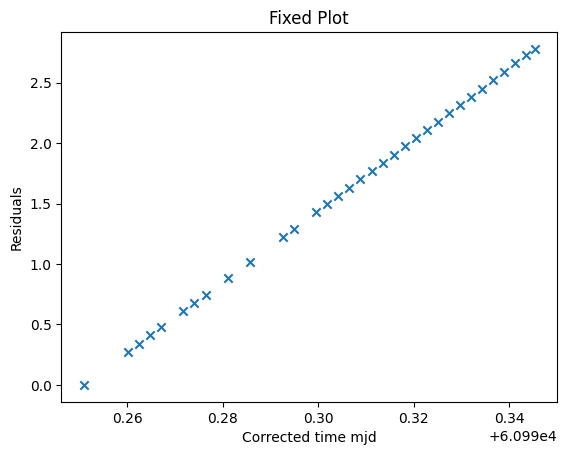

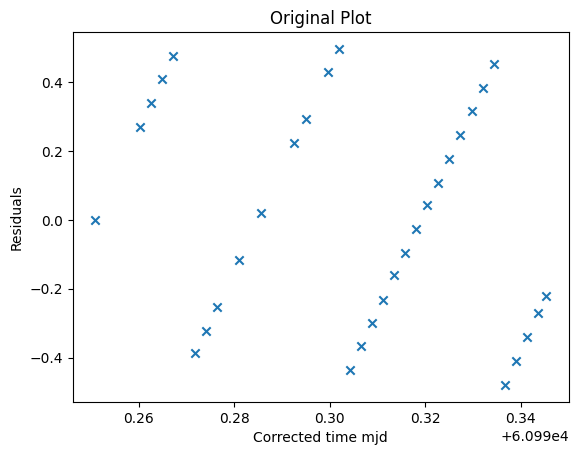

In [34]:

plt.scatter(corrected_time_mjd, residuals_new, marker='x')
plt.xlabel("Corrected time mjd")
plt.ylabel("Residuals")
plt.title("Fixed Plot")
plt.show()


plt.scatter(corrected_time_mjd, residuals, marker='x')
plt.xlabel("Corrected time mjd")
plt.ylabel("Residuals")
plt.title("Original Plot")
plt.show()



In [35]:
# @title
# reference_error = toa_uncertainty[0]
# sigma_R = [0.0000001]
# sqrt_2 = 1.41421356237
# first_term = sqrt_2 / period_guess

# for val in toa_uncertainty[1:]:         # skip first element
#     error_r = first_term * ((val**2 + reference_error**2)**0.5)
#     sigma_R.append(error_r)

# sigma_R = np.array(sigma_R)
# print(sigma_R)

# # Linear fit using polyfit + covariance matrix (weighted)
# # Weights = 1 / sigma
# fit, cov = np.polyfit(time_elapsed, residuals_new, 1, w=1/sigma_R, cov=True)

# slope_m = fit[0]
# intercept_c = fit[1]

# # Uncertainties = sqrt of diagonal of covariance matrix
# slope_unc = np.sqrt(cov[0, 0])
# intercept_unc = np.sqrt(cov[1, 1])

# print(f"Slope m = {slope_m:.6e} ± {slope_unc:.6e}")
# print(f"Intercept c = {intercept_c:.6e} ± {intercept_unc:.6e}")

# fit_line = slope_m * time_elapsed + intercept_c

# # Plot
# plt.figure(figsize=(10, 6))
# plt.errorbar(time_elapsed, residuals_new, xerr=sigma_R,
#              fmt='o', label='Unwrapped Residuals', capsize=5)

# plt.plot(time_elapsed, fit_line, 'r-',
#          label=f'Fit (slope = {slope_m:.3e} ± {slope_unc:.3e})')

# plt.axhline(0, color='k', linestyle='--')

# plt.xlabel('Time Elapsed from $t_0$ (s)')
# plt.ylabel('Residuals (cycles)')
# plt.title('Crab Pulsar Timing Residuals (Unwrapped)')
# plt.legend()
# plt.grid(True)
# plt.show()

# # Improved period
# print("Slope m =", slope_m)

# P_true = -1 / (slope_m - 1/period_guess)
# print("Improved Period P_true =", P_true)

# # Uncertainty in improved period using error propagation
# a = 1 / period_guess
# dP_dm = 1 / (slope_m - a)**2      # derivative of P_true wrt slope
# P_unc = abs(dP_dm) * slope_unc     # propagated uncertainty

# print(f"Uncertainty in Improved Period ΔP = {P_unc:.6e} s")
# N2 = time_elapsed / P_true
# N2_int = np.round(N2)
# residuals_corrected = N2 - N2_int

# plt.figure(figsize=(10, 6))
# plt.plot(time_elapsed, residuals_corrected, 'o', label='Corrected Residuals')
# plt.axhline(0, color='k', linestyle='--')

# plt.xlabel('Time Elapsed from $t_0$ (s)')
# plt.ylabel('Residuals (cycles)')
# plt.title('Residuals Using Improved Period')
# plt.legend()
# plt.grid(True)
# plt.show()



# # ====================================================
# # Calculate residuals from the fit
# residuals_from_fit = residuals_new - fit_line

# # Calculate chi-squared
# chi2 = np.sum((residuals_from_fit / sigma_R)**2)

# # Degrees of freedom
# n_data = len(time_elapsed)
# n_params = 2  # slope and intercept
# dof = n_data - n_params

# # Reduced chi-squared
# reduced_chi2 = chi2 / dof
# # ====================================================
# print(reduced_chi2)


In [36]:
# @title
# #Plotting, errors and fitting
# reference_error = toa_uncertainty[0]
# sigma_R = [0.0000001]
# sqrt_2 = 1.41421356237
# first_term = sqrt_2 / period_guess

# for val in toa_uncertainty[1:]:         # skip first element
#     error_r = first_term * ((val**2 + reference_error**2)**0.5)
#     sigma_R.append(error_r)

# sigma_R = np.array(sigma_R)
# #print(sigma_R)

# # Linear fit using polyfit + covariance matrix (weighted)
# # Weights = 1 / sigma
# fit, cov = np.polyfit(time_elapsed, residuals_new, 1, w=1/sigma_R, cov=True)

# slope_m = fit[0]
# intercept_c = fit[1]

# # Uncertainties = sqrt of diagonal of covariance matrix
# slope_unc = np.sqrt(cov[0, 0])
# intercept_unc = np.sqrt(cov[1, 1])

# fit_line = slope_m * time_elapsed + intercept_c

# # ====================================================
# # Calculate residuals from the fit
# residuals_from_fit = residuals_new - fit_line

# # Calculate chi-squared
# chi2 = np.sum((residuals_from_fit / sigma_R)**2)

# # Degrees of freedom
# n_data = len(time_elapsed)
# n_params = 2  # slope and intercept
# dof = n_data - n_params

# # Reduced chi-squared
# reduced_chi2 = chi2 / dof
# # ====================================================

# # Improved period
# P_true = -1 / (slope_m - 1/period_guess)


# # Uncertainty in improved period using error propagation
# a = 1 / period_guess
# dP_dm = 1 / (slope_m - a)**2      # derivative of P_true wrt slope
# P_unc = abs(dP_dm) * slope_unc     # propagated uncertainty


# N2 = time_elapsed / P_true
# N2_int = np.round(N2)
# residuals_corrected = N2 - N2_int

# print(residuals_corrected)
# #Plotting================================================
# plt.figure(figsize=(10, 6))
# plt.scatter(corrected_time_mjd, residuals, marker='x', color='#004A97')
# plt.xlabel("Corrected time mjd")
# plt.ylabel("Residuals")
# plt.title("Original Plot of the Residuals against Time in MJD")
# plt.grid()
# plt.show()


# plt.figure(figsize=(10, 6))
# plt.errorbar(time_elapsed, residuals_new, xerr=sigma_R,
#              fmt='x', label='Unwrapped Residuals', capsize=5, color='#004A97')

# plt.plot(time_elapsed, fit_line, '#F28500',
#          label=f'Fit (slope = {slope_m:.3e} ± {slope_unc:.3e})')

# plt.axhline(0, color='k', linestyle='--')

# plt.xlabel('Time Elapsed from $t_0$ (s)')
# plt.ylabel('Residuals (cycles)')
# plt.title('Crab Pulsar Timing Residuals (Unwrapped)')
# plt.legend()
# plt.grid(True)
# plt.show()
# print(f"Reduced chi-squared (χ²/ν) = {reduced_chi2:.2f} (ν = {dof})")
# #####Poly Chi

# coeff, cov = np.polyfit(time_elapsed, residuals_corrected, 3, w=1/sigma_R, cov=True)

# a, b, c, d = coeff
# # t^3, t^2, t, c
# # Evaluate the model
# sigma_a, sigma_b, sigma_c, sigma_d = np.sqrt(np.diag(cov))
# y_model = a*time_elapsed**3 + b*time_elapsed**2 + c*time_elapsed + d



# sigma_p_diff = ( (((-4*b*P_true)**2)*(P_unc)**2) + (((-2*P_true**2)**2)*(sigma_b)**2))**(1/2)
# sigma_nu_2_diff = (36*(sigma_a)**2)**(1/2)
# # Compute chi-squared
# chi2 = np.sum(((residuals_corrected - y_model) / sigma_R)**2)

# # Degrees of freedom: N - number_of_parameters (3 for a quadratic)
# dof = len(time_elapsed) - 4

# # Reduced chi-squared
# reduced_chi2 = chi2 / dof

# #Spin Down: Algebraically solved:
# s_d = abs(-2*b*P_true**2)
# v = 1/(P_true)
# first_v = 2*b
# second_v = (6*a)

# n = (v*second_v)/(first_v)**2
# m = (v)*(second_v)/(first_v)**2


# #=====================================
# #These are values assuming a Birth Period of 10ms
# #From it we can 'determine' when the Supernova was observed
# q = P_true / ((n-1)*s_d)
# P0 = 0.017 # Assuming 10ms Birth Period
# r = 1-((P0/P_true)**(1/(n-1)))
# T = q*r / (60*60*24*365)
# #print("Pulsar Age (Years):" ,T)
# #print("Estimate Year of Observation:", 2025-T)

# #======================================


# plt.figure(figsize=(10, 6))
# #plt.plot(time_elapsed, residuals_corrected, 'x', label='Corrected Residuals', color='#004A97')
# plt.errorbar(time_elapsed, residuals_corrected, xerr=sigma_R,
#              fmt='x', label='Unwrapped Residuals', capsize=5, color='#004A97')
# plt.plot(time_elapsed, y_model,color='r' )
# plt.axhline(0, color='k', linestyle='--')
# plt.xlabel('Time Elapsed from $t_0$ (s)')
# plt.ylabel('Residuals (cycles)')
# plt.title('Residuals Using Improved Period')
# plt.legend()
# plt.grid(True)
# plt.show()

# # Outputs
# print("\nCHI VALUES\n")
# #print(f"Slope m = {slope_m:.6e} ± {slope_unc:.6e}")
# #print(f"Intercept c = {intercept_c:.6e} ± {intercept_unc:.6e}")
# print(f"Chi-squared (χ²) = {chi2:.2f}")
# print(f"Reduced chi-squared (χ²/ν) = {reduced_chi2:.2f} (ν = {dof})")
# #print("Slope m =", slope_m)
# print("\nVALUES REGARDING FREQUENCY AND PERIOD \n")
# print("Improved Period P_true =", P_true)
# print(f"Uncertainty in Improved Period ΔP = {P_unc:.6e} s")

# print("Freq", v)
# print("1st Time Derivative Freq", first_v)
# print("2nd Time Derivative Freq", second_v)
# print("2nd Time Derivative Freq Uncertainty = ",sigma_nu_2_diff)
# print("Spin Down (Period Derivative) = ",s_d)
# print("Spin Down Uncertainty = ",sigma_p_diff)
# n = (v)*(1.1147E-20 )/(-3.77535E-10)**2  #Braking Index: Using Published Result for 2nd deriv
# print("Braking Index", n)

# #The following uses characterisitic age, in that the Birth period is
# #assumed much greater than its current period
# print("\nAGE\n")
# print("Actual Year of Observation:", 1054,"AD")
# character = (1/(4*b*P_true)) / (60*60*24*365)
# print("Characteristic Age", character)
# q = 1/(2*s_d)
# w = (-P_true/2)
# y = (s_d**(-2))
# sigma_character = (((q)**2)*((P_unc)**2) + ((w*y)**2)*((sigma_p_diff)**2)  ) **(1/2) / (60*60*24*365)
# print("Characteristic Age Uncertainty", sigma_character)

# j = ((n-1)/2)
# l = T/character
# i = 1/(n-1)
# P0_estimate = P_true*(1-(j*l))**i
# print("Estimate Birth Period", P0_estimate, "seconds")


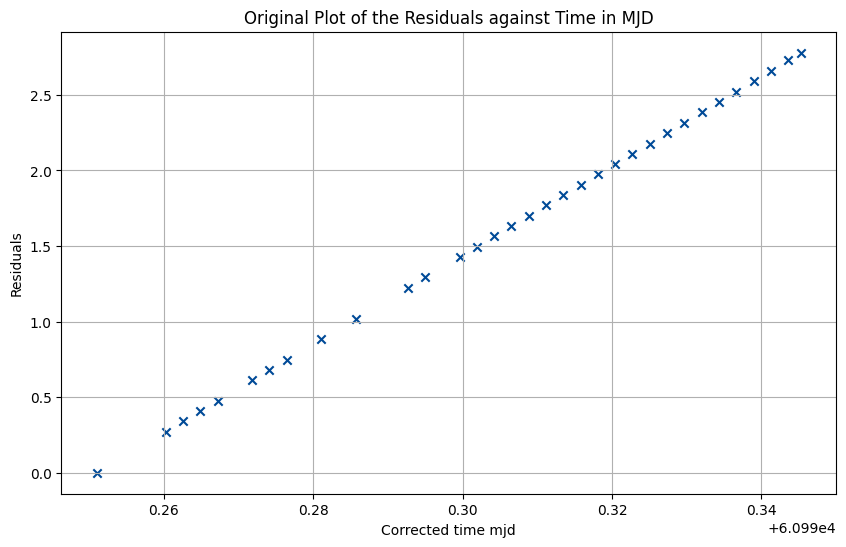

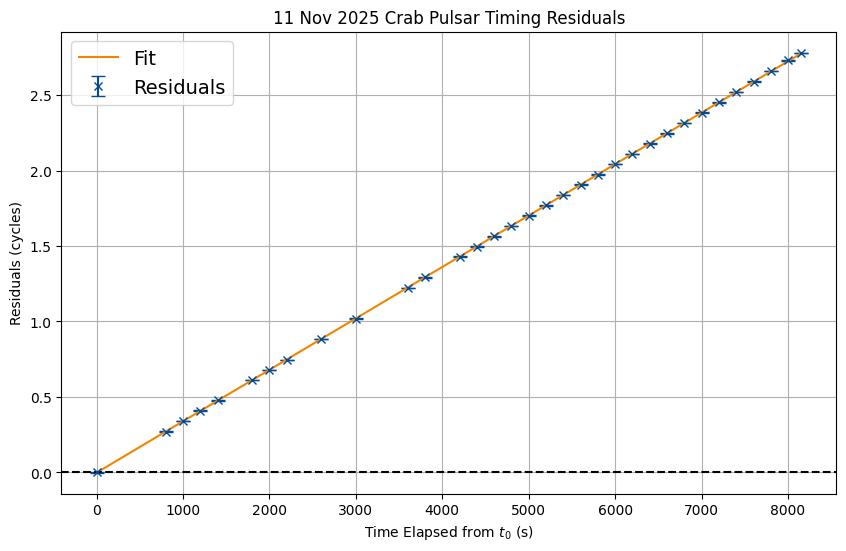

Reduced chi-squared (χ²/ν) = 1.07 (ν = 31)


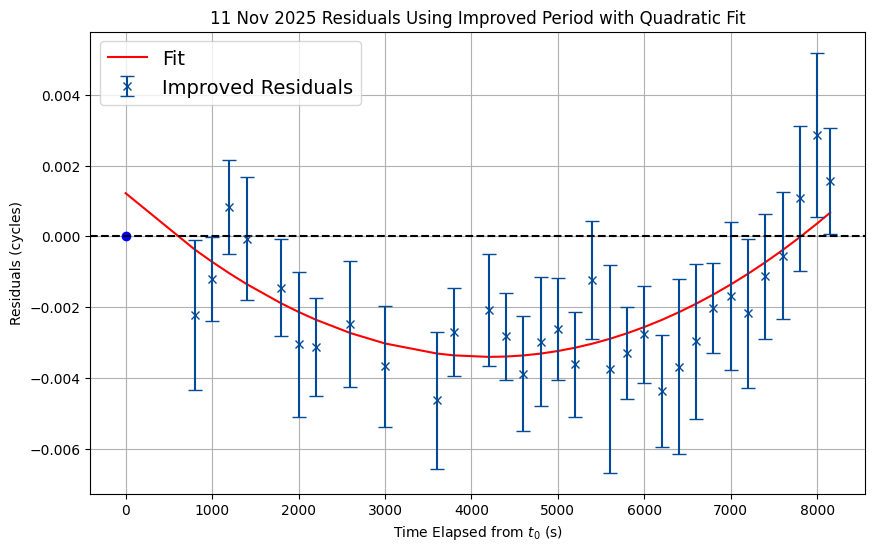


CHI VALUES

Chi-squared (χ²) = 12.30
Reduced chi-squared (χ²/ν) = 0.42 (ν = 29)

VALUES REGARDING FREQUENCY AND PERIOD 

Improved Period P_true = 0.0338482164063864
Uncertainty in Improved Period ΔP = 1.453332e-10 s
Freq 29.543654176452335
1st Time Derivative Freq 5.228094245765778e-10
Spin Down (Period Derivative) =  5.989836746894709e-13
Spin Down Uncertainty =  8.637443738252836e-14

AGE

Actual Year of Observation: 1054 AD
Characteristic Age 895.9508803177299
Characteristic Age Uncertainty 129.19760000127647


In [38]:
#Plotting, errors and fitting
# reference_error = toa_uncertainty[0]
# sigma_R = [0.0000001]
# sqrt_2 = 1.41421356237
# first_term = sqrt_2 / period_guess

# for val in toa_uncertainty[1:]:         # skip first element
#     error_r = first_term * ((val**2 + reference_error**2)**0.5)
#     sigma_R.append(error_r)
N_uncert = (((1/period_guess)**2)*(toa_uncertainty)**2)**(1/2)
sigma_R = N_uncert
sigma_R= sigma_R[mask]
#print('sigma_R =',sigma_R)

# Linear fit using polyfit + covariance matrix (weighted)
# Weights = 1 / sigma
fit, cov = np.polyfit(time_elapsed, residuals_new, 1, w=1/sigma_R, cov=True)

slope_m = fit[0]
intercept_c = fit[1]

# Uncertainties = sqrt of diagonal of covariance matrix
slope_unc = np.sqrt(cov[0, 0])
intercept_unc = np.sqrt(cov[1, 1])

fit_line = slope_m * time_elapsed + intercept_c

# ====================================================
# Calculate residuals from the fit
residuals_from_fit = residuals_new - fit_line

# Calculate chi-squared
chi2 = np.sum((residuals_from_fit / sigma_R)**2)

# Degrees of freedom
n_data = len(time_elapsed)
n_params = 2  # slope and intercept
dof = n_data - n_params

# Reduced chi-squared
reduced_chi2 = chi2 / dof
# ====================================================

# Improved period
P_true = -1 / (slope_m - 1/period_guess)


# Uncertainty in improved period using error propagation
a = 1 / period_guess
dP_dm = 1 / (slope_m - a)**2      # derivative of P_true wrt slope
P_unc = abs(dP_dm) * slope_unc     # propagated uncertainty


N2 = time_elapsed / P_true
N2_int = np.round(N2)
residuals_corrected = N2 - N2_int

#print(residuals_corrected)
#Plotting================================================

plt.figure(figsize=(10, 6))
plt.scatter(corrected_time_mjd, residuals_new, marker='x', color='#004A97')
plt.xlabel("Corrected time mjd")
plt.ylabel("Residuals")
plt.title("Original Plot of the Residuals against Time in MJD")
plt.grid()
plt.show()


plt.figure(figsize=(10, 6))
plt.errorbar(time_elapsed, residuals_new, yerr=sigma_R,
             fmt='x', label='Residuals', capsize=5, color='#004A97')

#plt.plot(time_elapsed, fit_line, '#F28500',
 #        label=f'Fit (slope = {slope_m:.3e} ± {slope_unc:.3e})')
plt.plot(time_elapsed, fit_line, '#F28500',
         label=f'Fit')

plt.axhline(0, color='k', linestyle='--')

plt.xlabel('Time Elapsed from $t_0$ (s)')
plt.ylabel('Residuals (cycles)')
plt.title('11 Nov 2025 Crab Pulsar Timing Residuals')
plt.legend(fontsize=14, loc='best')
plt.grid(True)
plt.show()
print(f"Reduced chi-squared (χ²/ν) = {reduced_chi2:.2f} (ν = {dof})")
#####Poly Chi

coeff, cov = np.polyfit(time_elapsed, residuals_corrected, 2, w=1/sigma_R, cov=True)

a, b, c = coeff
#t^2, t, c
sigma_a, sigma_b, sigma_c = np.sqrt(np.diag(cov))

# Evaluate the model
y_model = a*time_elapsed**2 + b*time_elapsed + c

sigma_p_diff = ( (((-4*a*P_true)**2)*(P_unc)**2) + (((-2*P_true**2)**2)*(sigma_a)**2))**(1/2)
#sigma_p_diff = (((-1/2*a)**2)*(sigma_a)**2)**(1/2)

#sigma_nu_2_diff = (36*(sigma_a)**2)**(1/2)
# Compute chi-squared
chi2 = np.sum(((residuals_corrected[1:] - y_model[1:]) / sigma_R[1:])**2)

# Degrees of freedom: N - number_of_parameters (3 for a quadratic)
dof = len(time_elapsed[1:]) - 3

# Reduced chi-squared
reduced_chi2 = chi2 / dof

#Spin Down: Algebraically solved:
s_d = 2*a*(P_true**2)

v = 1/(P_true)
first_v = 2*a
#second_v = (6*a)

#n = (v*second_v)/(first_v)**2
#m = (v)*(second_v)/(first_v)**2


#=====================================
#These are values assuming a Birth Period of 10ms
#From it we can 'determine' when the Supernova was observed
# q = P_true / ((n-1)*s_d)
# P0 = 0.017 # Assuming 10ms Birth Period
# r = 1-((P0/P_true)**(1/(n-1)))
# T = q*r / (60*60*24*365)
#print("Pulsar Age (Years):" ,T)
#print("Estimate Year of Observation:", 2025-T)

#======================================


plt.figure(figsize=(10, 6))
#plt.plot(time_elapsed, residuals_corrected, 'x', label='Corrected Residuals', color='#004A97')
plt.plot(time_elapsed, y_model,color='r', label='Fit' )
plt.plot([time_elapsed[0]], [residuals_corrected[0]], 'bo')
plt.errorbar(time_elapsed[1:], residuals_corrected[1:], yerr=sigma_R[1:],
             fmt='x', label='Improved Residuals', capsize=5, color='#004A97')

plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Time Elapsed from $t_0$ (s)')
plt.ylabel('Residuals (cycles)')
plt.title('11 Nov 2025 Residuals Using Improved Period with Quadratic Fit')
plt.legend(fontsize=14, loc='best')
plt.grid(True)
plt.show()

# Outputs
print("\nCHI VALUES\n")
#print(f"Slope m = {slope_m:.6e} ± {slope_unc:.6e}")
#print(f"Intercept c = {intercept_c:.6e} ± {intercept_unc:.6e}")
print(f"Chi-squared (χ²) = {chi2:.2f}")
print(f"Reduced chi-squared (χ²/ν) = {reduced_chi2:.2f} (ν = {dof})")
#print("Slope m =", slope_m)
print("\nVALUES REGARDING FREQUENCY AND PERIOD \n")
print("Improved Period P_true =", P_true)
print(f"Uncertainty in Improved Period ΔP = {P_unc:.6e} s")

print("Freq", v)
print("1st Time Derivative Freq", first_v)
#print("2nd Time Derivative Freq", second_v)
#print("2nd Time Derivative Freq Uncertainty = ",sigma_nu_2_diff)
print("Spin Down (Period Derivative) = ",s_d)
print("Spin Down Uncertainty = ",sigma_p_diff)
#n = (v)*(1.1147E-20 )/(-3.77535E-10)**2  #Braking Index: Using Published Result for 2nd deriv
#print("Braking Index", n)

#The following uses characterisitic age, in that the Birth period is
#assumed much greater than its current period
print("\nAGE\n")
print("Actual Year of Observation:", 1054,"AD")
character = (1/(4*a*P_true)) / (60*60*24*365)
print("Characteristic Age", character)
q = 1/(2*s_d)
w = (-P_true/2)
y = (s_d**(-2))
sigma_character = (((q)**2)*((P_unc)**2) + ((w*y)**2)*((sigma_p_diff)**2)  ) **(1/2) / (60*60*24*365)
print("Characteristic Age Uncertainty", sigma_character)

#j = ((n-1)/2)
#l = T/character
#i = 1/(n-1)
#P0_estimate = P_true*(1-(j*l))**i
#print("Estimate Birth Period", P0_estimate, "seconds")


In [39]:
from datetime import datetime
import pytz

period_1 = 0.033848731728117976 #20251119 # f
uncert_1 = 1.736186e-10

period_2 = 0.03384821601740401  #20251111 # o
uncert_2 = 7.943353e-11


# Define the two dates
date1 = datetime(2025, 11, 19, 18, 45, 1)
date2 = datetime(2025, 11, 11, 5, 49, 31)

# Calculate the time difference
time_diff = date1 - date2

# Convert to seconds
seconds_diff = time_diff.total_seconds()

print(f"Date 1: {date1}")
print(f"Date 2: {date2}")
print(f"Time difference: {time_diff}")
print(f"Time difference in seconds: {seconds_diff:,.0f} seconds")
print(f"Time difference in days: {seconds_diff / 86400:.2f} days")

period_derivative = (period_1 - period_2)/seconds_diff
print("Period derivative:", period_derivative)

c = (1 / period_1 - period_2)

sigma_period_deriv = ( ((c)**2)*(uncert_1)**2 + ((-c)**2)*(uncert_2)**2)**(1/2)
print("Period derivative Uncertainty :", sigma_period_deriv)


surface_b_1 = (3.2*10**19)*(P_true*period_derivative)**0.5

surface_b_2 = (3.2*10**19)*(P_true*s_d)**0.5
print("Surface magnetic field:", surface_b_1, "Gauss")
print("(The Better) Surface magnetic field:", surface_b_2, "Gauss")
C = 1.6e19
sigma_b = ( (((C*np.sqrt(P_true/s_d))**2)*(sigma_p_diff)**2) + ((C*np.sqrt(s_d/P_true))**2)*(P_unc)**2)**(1/2)
print("B Uncertainty:", sigma_b)


Date 1: 2025-11-19 18:45:01
Date 2: 2025-11-11 05:49:31
Time difference: 8 days, 12:55:30
Time difference in seconds: 737,730 seconds
Time difference in days: 8.54 days
Period derivative: 6.990507556509679e-13
Period derivative Uncertainty : 5.6341316592865516e-09
Surface magnetic field: 4922347018087.37 Gauss
(The Better) Surface magnetic field: 4556436956861.855 Gauss
B Uncertainty: 328522875704.3624
